<a href="https://colab.research.google.com/github/drm69/PCVK25_3F_12/blob/main/Week10_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

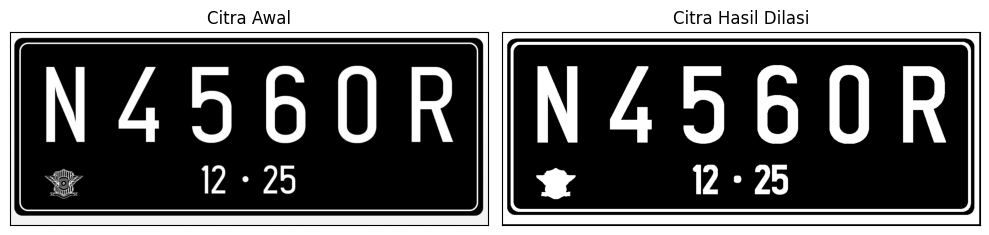

In [23]:
def dilasi_citra(F, w):
    # Ukuran citra
    p, q = F.shape
    imgD = np.zeros((p, q), dtype=np.uint8)

    # Generate struktur elemen dilasi (SED)
    SED = np.ones((w, w), dtype=np.uint8)
    constant1 = (w - 1) // 2

    # Proses dilasi
    for i in range(constant1, p - constant1):
        for j in range(constant1, q - constant1):
            temp = F[i - constant1:i + constant1 + 1, j - constant1:j + constant1 + 1]
            product = temp * SED
            imgD[i, j] = np.max(product)

    return imgD


# Membaca citra grayscale
img_d = cv2.imread('/content/drive/MyDrive/images/plat_nomor.jpg', 0)

# Threshold citra
ret, thresh = cv2.threshold(img_d, 125, 200, cv2.THRESH_BINARY)

# Ukuran struktur elemen
w = 5

# Proses dilasi
imgD = dilasi_citra(thresh, w)

# Tampilkan hasil
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1), plt.imshow(img_d, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])

plt.subplot(1, 2, 2), plt.imshow(imgD, cmap='gray')
plt.title('Citra Hasil Dilasi'), plt.xticks([]), plt.yticks([])

plt.tight_layout()
plt.show()

[[1 1 1]
 [1 1 1]
 [1 1 1]]


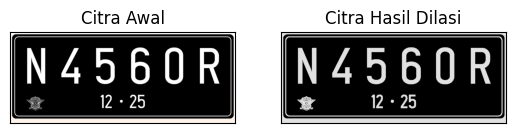

In [24]:
img = cv2.imread('/content/drive/MyDrive/images/plat_nomor.jpg')
# img = cv2.imread('morp.jpg', 0)

ret, thresh = cv2.threshold(img, 127, 225, cv2.THRESH_BINARY)
kernel = np.ones((3, 3), np.uint16)
dilasi = cv2.dilate(thresh, kernel, iterations=1)

print(kernel)

plt.subplot(121), plt.imshow(img), plt.title('Citra Awal')
plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(dilasi), plt.title('Citra Hasil Dilasi')
plt.xticks([]), plt.yticks([])
plt.show()

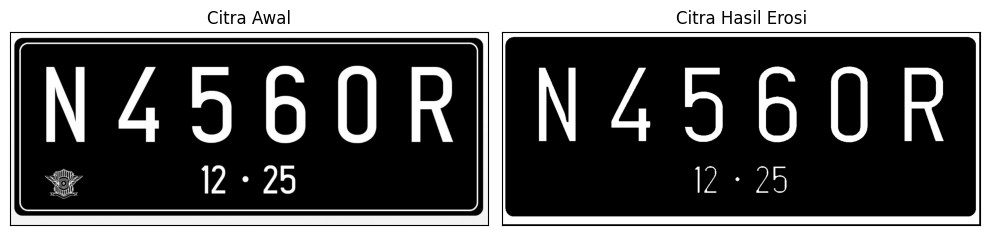

In [25]:
# Erosi Tanpa Library
def erosi_citra(F, k):
    # Ukuran citra
    m, n = F.shape

    # Generate structure element erosi (SE)
    SE = np.ones((k, k), dtype=np.uint8)
    constant = (k - 1) // 2
    imgE = np.zeros((m, n), dtype=np.uint8)

    # Proses Erosi
    for i in range(constant, m - constant):
        for j in range(constant, n - constant):
            temp = F[i - constant:i + constant + 1, j - constant:j + constant + 1]
            product = temp * SE
            imgE[i, j] = np.min(product)

    return imgE


# Membaca citra grayscale
img_e = cv2.imread('/content/drive/MyDrive/images/plat_nomor.jpg', 0)

# Threshold citra
ret1, thresh1 = cv2.threshold(img_e, 175, 225, cv2.THRESH_BINARY)

# Ukuran struktur elemen
k = 5

# Proses erosi
imgE = erosi_citra(thresh1, k)

# Tampilkan hasil
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1), plt.imshow(img_e, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])

plt.subplot(1, 2, 2), plt.imshow(imgE, cmap='gray')
plt.title('Citra Hasil Erosi'), plt.xticks([]), plt.yticks([])

plt.tight_layout()
plt.show()

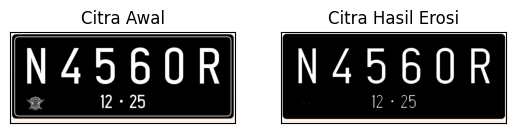

In [26]:
# Erosi Library
img = cv2.imread('/content/drive/MyDrive/images/plat_nomor.jpg')
kernel = np.ones((5, 5), np.uint8)
erosion = cv2.erode(img, kernel, iterations=1)

plt.subplot(121), plt.imshow(img), plt.title('Citra Awal')
plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(erosion), plt.title('Citra Hasil Erosi')
plt.xticks([]), plt.yticks([])
plt.show()

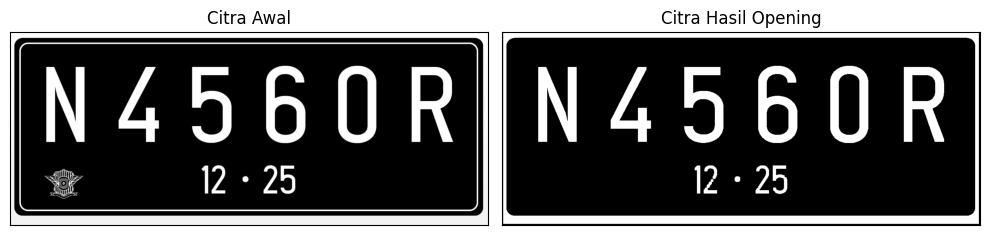

In [27]:
img_o = cv2.imread('/content/drive/MyDrive/images/plat_nomor.jpg', 0)

# Threshold citra
reto, thresho = cv2.threshold(img_o, 127, 225, cv2.THRESH_BINARY)

# Ukuran kernel
k = 7

# Proses Opening (Erosi kemudian Dilasi)
imgO = dilasi_citra(erosi_citra(thresho, k), k)

# Tampilkan hasil
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1), plt.imshow(img_o, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])

plt.subplot(1, 2, 2), plt.imshow(imgO, cmap='gray')
plt.title('Citra Hasil Opening'), plt.xticks([]), plt.yticks([])

plt.tight_layout()
plt.show()

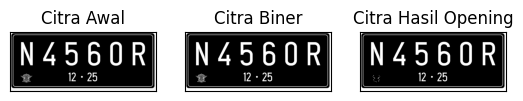

In [28]:
# Dengan Menggunakan Library
img = cv2.imread('/content/drive/MyDrive/images/plat_nomor.jpg', 0)
ret, thresh = cv2.threshold(img, 127, 225, cv2.THRESH_BINARY)
kernel = np.ones((3, 3), np.uint8)
openn = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

plt.subplot(131), plt.imshow(img, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])

plt.subplot(132), plt.imshow(thresh, cmap='gray')
plt.title('Citra Biner'), plt.xticks([]), plt.yticks([])

plt.subplot(133), plt.imshow(openn, cmap='gray')
plt.title('Citra Hasil Opening'), plt.xticks([]), plt.yticks([])

plt.show()

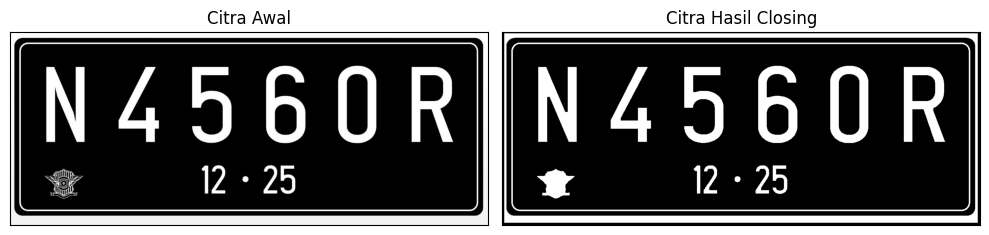

In [29]:
img_c = cv2.imread('/content/drive/MyDrive/images/plat_nomor.jpg', 0)

# Threshold citra
retc, threshc = cv2.threshold(img_c, 127, 225, cv2.THRESH_BINARY)

# Ukuran kernel
k = 7

# Proses Closing (Dilasi kemudian Erosi)
imgC = erosi_citra(dilasi_citra(threshc, k), k)

# Tampilkan hasil
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1), plt.imshow(img_c, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])

plt.subplot(1, 2, 2), plt.imshow(imgC, cmap='gray')
plt.title('Citra Hasil Closing'), plt.xticks([]), plt.yticks([])

plt.tight_layout()
plt.show()

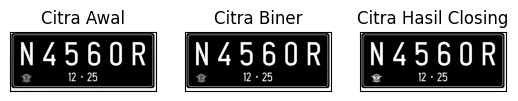

In [30]:
# Dengan Menggunakan Library
img = cv2.imread('/content/drive/MyDrive/images/plat_nomor.jpg', 0)
ret, thresh = cv2.threshold(img, 127, 225, cv2.THRESH_BINARY)

kernel = np.ones((3, 3), np.uint8)
closs = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

plt.subplot(131), plt.imshow(img, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])

plt.subplot(132), plt.imshow(thresh, cmap='gray')
plt.title('Citra Biner'), plt.xticks([]), plt.yticks([])

plt.subplot(133), plt.imshow(closs, cmap='gray')
plt.title('Citra Hasil Closing'), plt.xticks([]), plt.yticks([])

plt.show()

SED = Cross 3


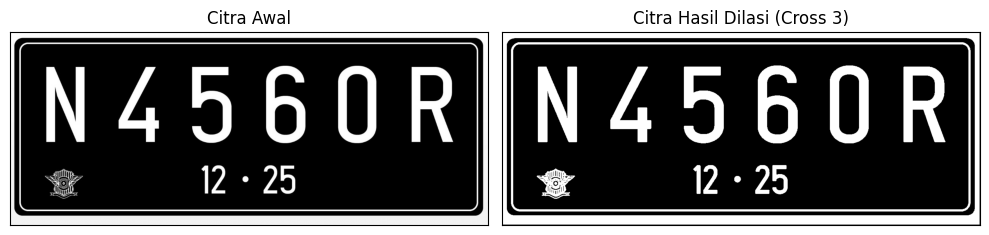

SED = Cross 5


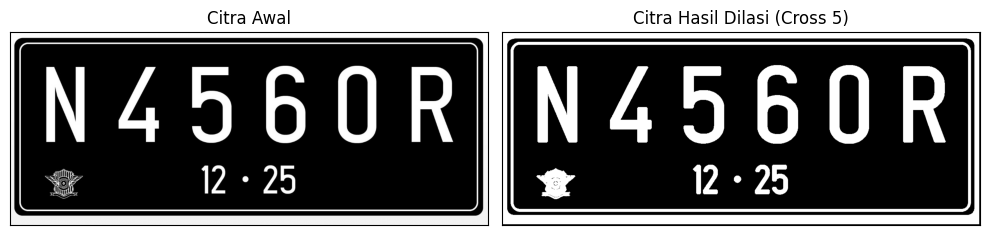

In [31]:
# ==========================================================
# Dilasi dengan SED Cross 3x3
# ==========================================================
def dilasi_citra(F, w):
    # Size image
    p, q = F.shape
    imgD = np.zeros((p, q), dtype=np.uint8)

    # Generate structure element dilasi (SED)
    SED = np.array([[0, 1, 0],
                    [1, 1, 1],
                    [0, 1, 0]], dtype=np.uint8)

    constant1 = (w - 1) // 2

    # Proses Dilasi
    for i in range(constant1, p - constant1):
        for j in range(constant1, q - constant1):
            temp = F[i - constant1:i + constant1 + 1,
                     j - constant1:j + constant1 + 1]
            product = temp * SED
            imgD[i, j] = np.max(product)

    return imgD


print('SED = Cross 3')

img_d = cv2.imread('/content/drive/MyDrive/images/plat_nomor.jpg', 0)
ret, thresh = cv2.threshold(img_d, 127, 225, cv2.THRESH_BINARY)
w = 3
imgD = dilasi_citra(thresh, w)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1), plt.imshow(img_d, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])

plt.subplot(1, 2, 2), plt.imshow(imgD, cmap='gray')
plt.title('Citra Hasil Dilasi (Cross 3)'), plt.xticks([]), plt.yticks([])
plt.tight_layout()
plt.show()


# ==========================================================
# Dilasi dengan SED Cross 5x5
# ==========================================================
def dilasi_citra(F, w):
    # Size image
    p, q = F.shape
    imgD = np.zeros((p, q), dtype=np.uint8)

    # Generate structure element dilasi (SED)
    SED = np.array([[0, 0, 1, 0, 0],
                    [0, 0, 1, 0, 0],
                    [1, 1, 1, 1, 1],
                    [0, 0, 1, 0, 0],
                    [0, 0, 1, 0, 0]], dtype=np.uint8)

    constant1 = (w - 1) // 2

    # Proses Dilasi
    for i in range(constant1, p - constant1):
        for j in range(constant1, q - constant1):
            temp = F[i - constant1:i + constant1 + 1,
                     j - constant1:j + constant1 + 1]
            product = temp * SED
            imgD[i, j] = np.max(product)

    return imgD


print('SED = Cross 5')

img_d = cv2.imread('/content/drive/MyDrive/images/plat_nomor.jpg', 0)
ret, thresh = cv2.threshold(img_d, 127, 225, cv2.THRESH_BINARY)
w = 5
imgD = dilasi_citra(thresh, w)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1), plt.imshow(img_d, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])

plt.subplot(1, 2, 2), plt.imshow(imgD, cmap='gray')
plt.title('Citra Hasil Dilasi (Cross 5)'), plt.xticks([]), plt.yticks([])
plt.tight_layout()
plt.show()

SED = Circle 3


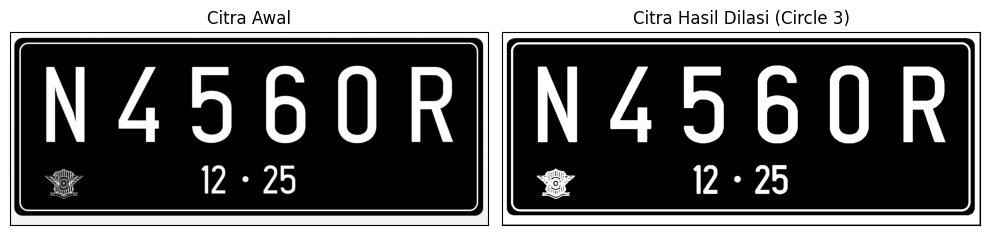

SED = Circle 5


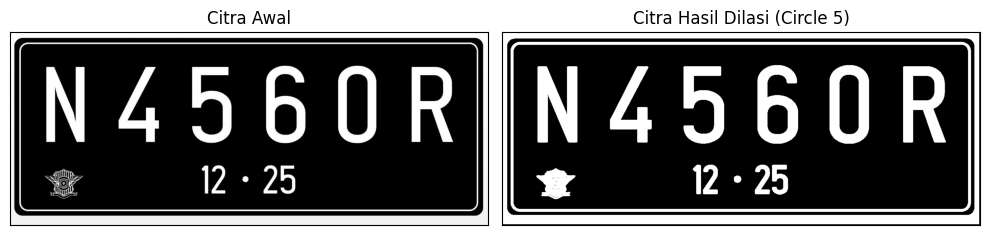

In [32]:
# ==========================================================
# Dilasi dengan Circular Structuring Element
# ==========================================================
def dilasi_citra(F, w):
    # Size image
    p, q = F.shape
    imgD = np.zeros((p, q), dtype=np.uint8)

    # Generate structure element dilasi (SED)
    SED = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (w, w))
    constant1 = (w - 1) // 2

    # Proses Dilasi
    for i in range(constant1, p - constant1):
        for j in range(constant1, q - constant1):
            temp = F[i - constant1:i + constant1 + 1,
                     j - constant1:j + constant1 + 1]
            product = temp * SED
            imgD[i, j] = np.max(product)

    return imgD


# ==========================================================
# Circular SED ukuran 3
# ==========================================================
print('SED = Circle 3')

img_d = cv2.imread('/content/drive/MyDrive/images/plat_nomor.jpg', 0)
ret, thresh = cv2.threshold(img_d, 127, 225, cv2.THRESH_BINARY)
w = 3
imgD = dilasi_citra(thresh, w)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1), plt.imshow(img_d, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])

plt.subplot(1, 2, 2), plt.imshow(imgD, cmap='gray')
plt.title('Citra Hasil Dilasi (Circle 3)'), plt.xticks([]), plt.yticks([])
plt.tight_layout()
plt.show()


# ==========================================================
# Circular SED ukuran 5
# ==========================================================
print('SED = Circle 5')

img_d = cv2.imread('/content/drive/MyDrive/images/plat_nomor.jpg', 0)
ret, thresh = cv2.threshold(img_d, 127, 225, cv2.THRESH_BINARY)
w = 5
imgD = dilasi_citra(thresh, w)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1), plt.imshow(img_d, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])

plt.subplot(1, 2, 2), plt.imshow(imgD, cmap='gray')
plt.title('Citra Hasil Dilasi (Circle 5)'), plt.xticks([]), plt.yticks([])
plt.tight_layout()
plt.show()

SE = Rectangle 3x5


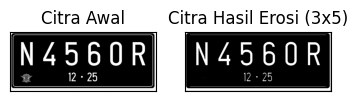

SE = Rectangle 5x7


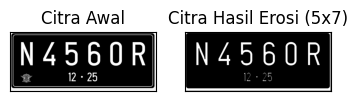

In [33]:
# Erosi Cross SE
def erosi_citra(F, p, l):
    # size image
    m, n = F.shape

    # Generate structure element erosi (SE)
    SE = cv2.getStructuringElement(cv2.MORPH_RECT, (p, l))  # SE persegi panjang
    constant1 = (l - 1) // 2
    constant2 = (p - 1) // 2

    # print(SE)
    imgE = np.zeros((m, n), dtype=np.uint8)

    # Proses Erosi
    for i in range(constant1, m - constant1):
        for j in range(constant2, n - constant2):
            temp = F[i - constant1:i + constant1 + 1, j - constant2:j + constant2 + 1]
            product = temp * SE
            imgE[i, j] = np.min(product)

    return imgE


# SE = Rectangle 3x5
print('SE = Rectangle 3x5')
img_e = cv2.imread('/content/drive/MyDrive/images/plat_nomor.jpg', 0)
ret1, thresh1 = cv2.threshold(img_e, 127, 225, cv2.THRESH_BINARY)
p = 5
l = 3
imgE = erosi_citra(thresh1, p, l)

plt.subplot(131), plt.imshow(img_e, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
plt.subplot(132), plt.imshow(imgE, cmap='gray')
plt.title('Citra Hasil Erosi (3x5)'), plt.xticks([]), plt.yticks([])
plt.show()

# SE = Rectangle 5x7
print('SE = Rectangle 5x7')
img_e = cv2.imread('/content/drive/MyDrive/images/plat_nomor.jpg', 0)
ret1, thresh1 = cv2.threshold(img_e, 127, 225, cv2.THRESH_BINARY)
p = 7
l = 5
imgE = erosi_citra(thresh1, p, l)

plt.subplot(131), plt.imshow(img_e, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
plt.subplot(132), plt.imshow(imgE, cmap='gray')
plt.title('Citra Hasil Erosi (5x7)'), plt.xticks([]), plt.yticks([])
plt.show()

SE = Line Vertikal 3


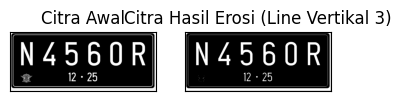

SE = Line Vertikal 5


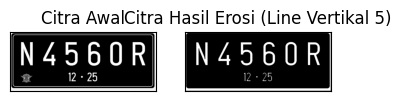

In [34]:
# Erosi Line Vertikal SE
def erosi_citra(F, k):
    # size image
    m, n = F.shape

    # Generate structure element erosi (SE)
    SE = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (1, k))  # SE line vertikal
    constant = (k - 1) // 2
    imgE = np.zeros((m, n), dtype=np.uint8)

    # Proses Erosi
    for i in range(constant, m - constant):
        for j in range(constant, n - constant):
            temp = F[i - constant:i + constant + 1, j - constant:j + constant + 1]
            product = temp * SE
            imgE[i, j] = np.min(product)

    return imgE


# SE = Line Vertikal 3
print('SE = Line Vertikal 3')
img_e = cv2.imread('/content/drive/MyDrive/images/plat_nomor.jpg', 0)
ret1, thresh1 = cv2.threshold(img_e, 127, 225, cv2.THRESH_BINARY)
k = 3
imgE = erosi_citra(thresh1, k)

plt.subplot(131), plt.imshow(img_e, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
plt.subplot(132), plt.imshow(imgE, cmap='gray')
plt.title('Citra Hasil Erosi (Line Vertikal 3)'), plt.xticks([]), plt.yticks([])
plt.show()


# SE = Line Vertikal 5
print('SE = Line Vertikal 5')
img_e = cv2.imread('/content/drive/MyDrive/images/plat_nomor.jpg', 0)
ret1, thresh1 = cv2.threshold(img_e, 127, 225, cv2.THRESH_BINARY)
k = 5
imgE = erosi_citra(thresh1, k)

plt.subplot(131), plt.imshow(img_e, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
plt.subplot(132), plt.imshow(imgE, cmap='gray')
plt.title('Citra Hasil Erosi (Line Vertikal 5)'), plt.xticks([]), plt.yticks([])
plt.show()

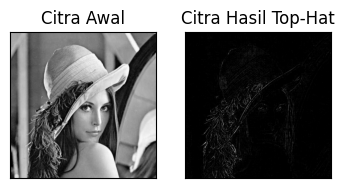

In [35]:
# Getting the kernel to be used in Top-Hat
filterSize = (3, 3)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, filterSize)

# Reading the image named 'plat nomer.jpg'
img = cv2.imread('/content/drive/MyDrive/images/lena.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Applying the Top-Hat operation
tophat_img = cv2.morphologyEx(img, cv2.MORPH_TOPHAT, kernel)

# Displaying the results
plt.subplot(131), plt.imshow(img, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])

plt.subplot(132), plt.imshow(tophat_img, cmap='gray')
plt.title('Citra Hasil Top-Hat'), plt.xticks([]), plt.yticks([])

plt.show()

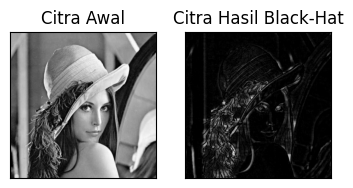

In [36]:
# Membuat kernel untuk operasi Black-Hat
filterSize = (3, 3)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, filterSize)

# Membaca citra 'kitten01.jpg'
img = cv2.imread('/content/drive/MyDrive/images/lena.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Menerapkan operasi Black-Hat dengan kernel persegi panjang
Kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (13, 5))
blackhat = cv2.morphologyEx(img, cv2.MORPH_BLACKHAT, Kernel)

# Menampilkan hasil
plt.subplot(131), plt.imshow(img, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])

plt.subplot(132), plt.imshow(blackhat, cmap='gray')
plt.title('Citra Hasil Black-Hat'), plt.xticks([]), plt.yticks([])

plt.show()

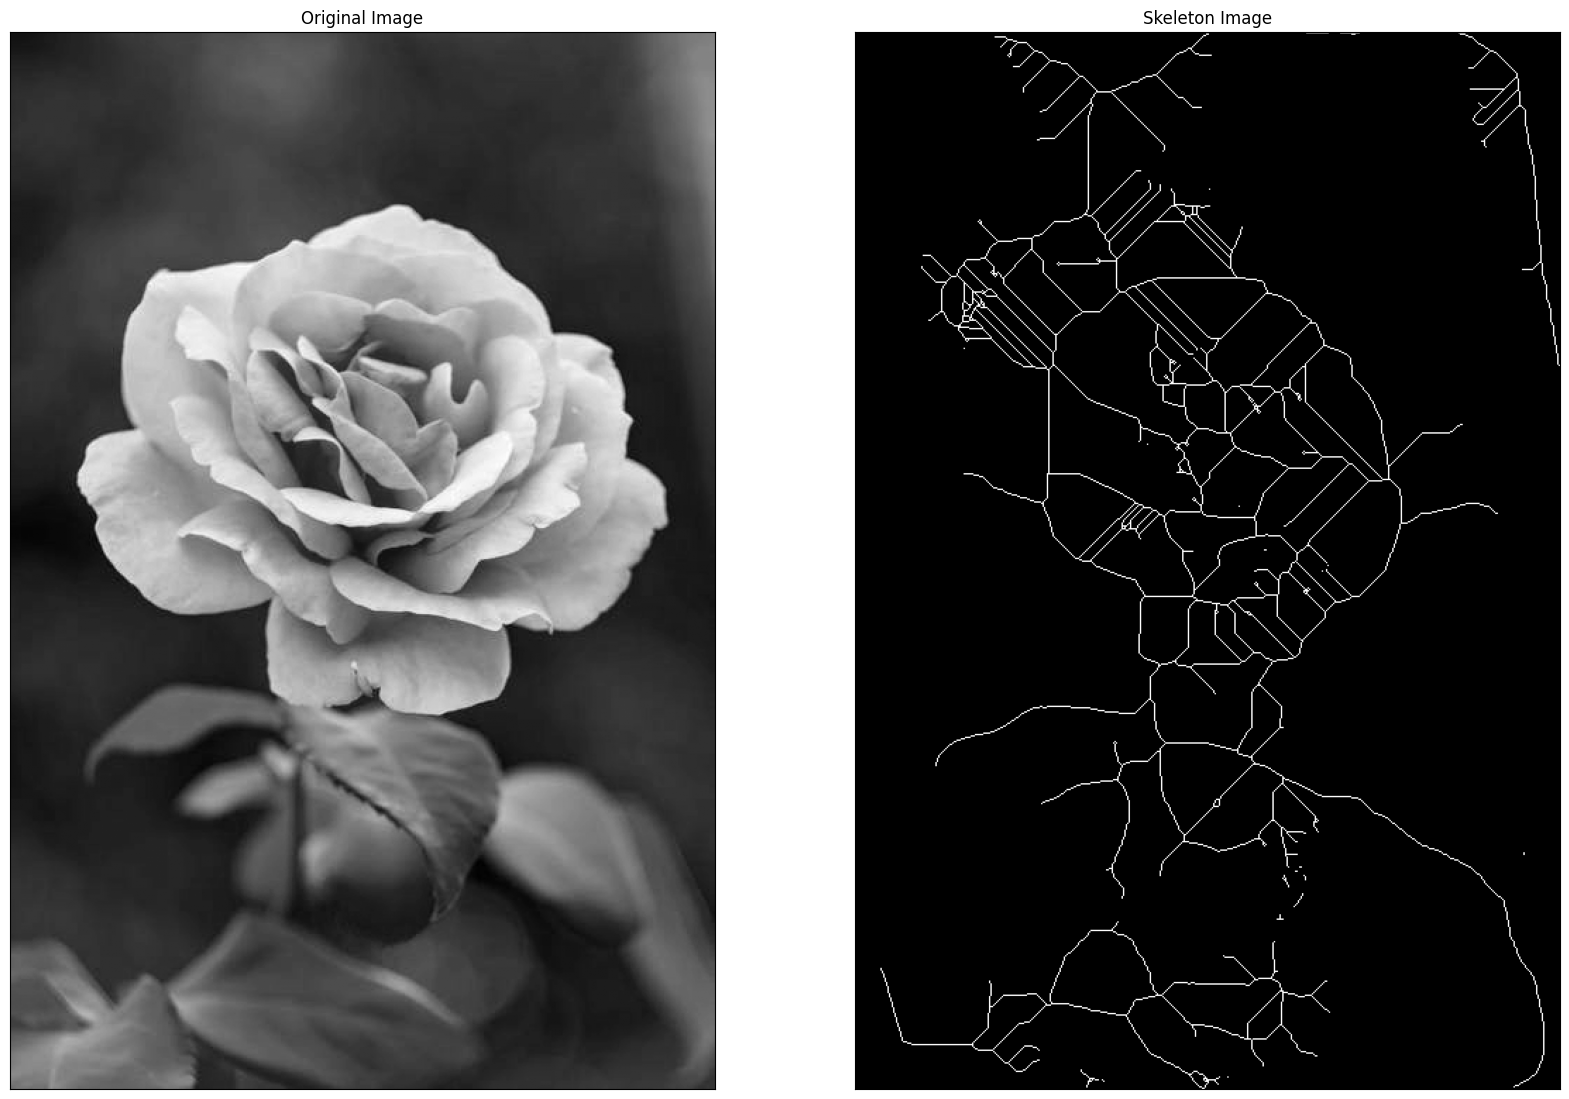

In [37]:
import cv2 as cv
from matplotlib import pyplot as plt
from skimage import filters
from skimage.morphology import skeletonize

# Membaca citra dalam mode grayscale
img = cv.imread('/content/drive/MyDrive/images/rose_pink.png', 0)

# Membuat citra biner menggunakan metode threshold Triangle
binary = img > filters.threshold_triangle(img)

# Mengonversi nilai True/False menjadi 1/0
binary_cp = binary.copy()
binary_cp[binary_cp == True] = 1
binary_cp[binary_cp == False] = 0

# Melakukan proses skeletonisasi
skeleton = skeletonize(binary_cp)

# Menampilkan hasil
plt.figure(figsize=(20, 20))
plt.subplot(121), plt.imshow(img, cmap='gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])

plt.subplot(122), plt.imshow(skeleton, cmap='gray')
plt.title('Skeleton Image'), plt.xticks([]), plt.yticks([])

# Menyimpan hasil ke file
plt.savefig("binary_and_bin_skeleton.png")
plt.show()

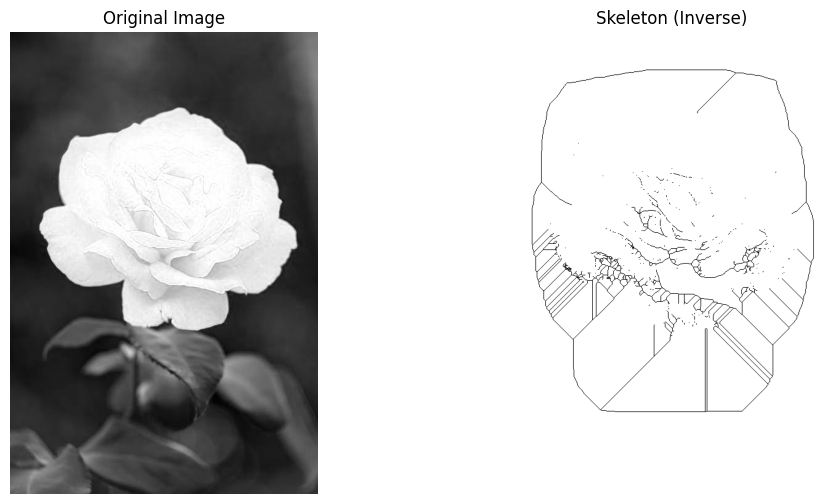

In [38]:
from skimage import io, filters
from skimage.morphology import skeletonize
from matplotlib import pyplot as plt

# Membaca citra (mengambil channel pertama)
img = io.imread('/content/drive/MyDrive/images/rose_pink.png')[..., 0]

# Membuat citra biner — bagian hitam menjadi True
binary = img < filters.threshold_triangle(img)

# Melakukan skeletonisasi pada citra biner
skeleton = skeletonize(binary)

# Menampilkan hasil
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original Image')
ax[0].set_axis_off()

# Catatan: menggunakan colormap terbalik (gray_r)
ax[1].imshow(skeleton, cmap='gray_r')
ax[1].set_title('Skeleton (Inverse)')
ax[1].set_axis_off()

plt.show()

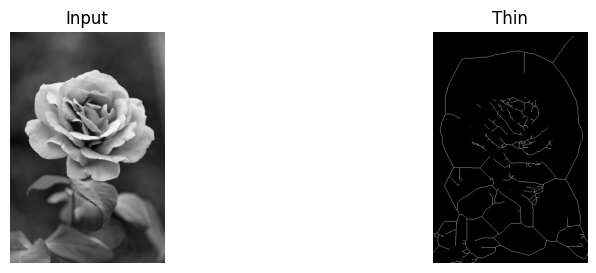

In [39]:
from skimage import img_as_float, io, color, morphology
import matplotlib.pyplot as plt

# Membaca citra dan mengonversi ke grayscale (float)
image = img_as_float(color.rgb2gray(io.imread('/content/drive/MyDrive/images/rose_pink.png')))

# Membuat citra biner
image_binary = image < 0.5

# Proses skeletonisasi dan thinning
out_skeletonize = morphology.skeletonize(image_binary)
out_thin = morphology.thin(image_binary)

# Menampilkan hasil
f, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 3))
ax0.imshow(image, cmap='gray')
ax0.set_title('Input')
ax0.axis('off')

ax1.imshow(out_thin, cmap='gray')
ax1.set_title('Thin')
ax1.axis('off')

# Menyimpan hasil
plt.savefig('/tmp/char_out.png')
plt.show()